<a href="https://colab.research.google.com/github/abdelrahman-rajab-hassan/machine-learning-lab/blob/main/supervised-machine-learning/classification-metrics-(core)/Classification_Metrics_(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier

from sklearn import set_config
set_config(transform_output = 'pandas')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/02-IntroML/Week07/Data/stroke.csv'
df = pd.read_csv(path)

df = df.set_index('id')
df.head()



,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


In [ ]:
# check if the column age has any non-numerical value using a regix code
df['age'].str.contains('[^0-9.]').sum()

# find the non-numerical value
df[df['age'].str.contains('[^0-9.]')]

# change the value from *82 to 82
df.loc[df['age'] == '*82', 'age'] = '82'

# check if the column age has any non-numerical value using a regix code
df['age'].str.contains('[^0-9.]').sum()

# check age data type
df['age'].dtype

# modify the column data type
df['age'] = df['age'].astype(int)

# re-check the dtype
df['age'].dtype


dtype('int64')

In [ ]:
# modify hypertension and heartdisease so 0 is No, and 1 is Yes
df['hypertension'] = df['hypertension'].replace({0: 'No', 1: 'Yes'})
df['heart_disease'] = df['heart_disease'].replace({0: 'No', 1: 'Yes'})

# modify the type to by an object
df['hypertension'] = df['hypertension'].astype(str)
df['heart_disease'] = df['heart_disease'].astype(str)

In [ ]:
# check all dtypes for all columns
df.dtypes

,0
gender,object
age,int64
hypertension,object
heart_disease,object
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64
smoking_status,object


In [ ]:
# class balnace for strke column
df['stroke'].value_counts()

,count
stroke,
0,1000
1,137


> The column is heavily skewed toward healthy individuals, with stroke cases being a small minority.

In [ ]:
# set the target column or positive class
y = df['stroke']

# drop the stroke column
X = df.drop('stroke', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
id,,,,,,,,,,
21608,Male,56,Yes,No,Yes,Govt_job,Urban,72.79,23.8,smokes
61960,Male,82,No,Yes,Yes,Private,Urban,144.90,26.4,smokes
16971,Female,26,No,No,No,Private,Urban,100.31,38.6,never smoked
1505,Male,71,No,Yes,Yes,Self-employed,Rural,101.13,35.9,formerly smoked
32235,Female,45,Yes,No,Yes,Govt_job,Rural,95.02,NaN,smokes


In [ ]:
# Identify numerical columns, excluding 'hypertension' and 'heart_disease'
num_cols = X_train.select_dtypes('number').columns

print(f"Numerical columns for processing: {num_cols}")

# Create a pipeline for numerical features
num_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())])

# Create the numerical tuple
num_tuple = ('numerical', num_pipe, num_cols)

num_tuple

Numerical columns for processing: Index(['age', 'avg_glucose_level', 'bmi'], dtype='object')


('numerical',
 Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())]),
 Index(['age', 'avg_glucose_level', 'bmi'], dtype='object'))

In [ ]:
# Identify categorical columns
cat_cols = X_train.select_dtypes(include='object').columns

nominal_cols = cat_cols

print(f"Categorical columns for processing: {nominal_cols}")

# Create a pipeline for nominal categorical features (OneHotEncoder)
nominal_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output = False))
])

# Create the nominal tuple
nominal_tuple = ('nominal', nominal_pipe, nominal_cols)

nominal_tuple

Categorical columns for processing: Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status'],
      dtype='object')


('nominal',
 Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                 ('onehot',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
        'Residence_type', 'smoking_status'],
       dtype='object'))

In [ ]:
# Combine numerical and categorical pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        num_tuple,
        nominal_tuple
    ],
    verbose_feature_names_out = False
)

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'avg_glucose_level', 'bmi'], dtype='object')),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [ ]:
model_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

model_pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [ ]:
model_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('classifier', DecisionTreeClassifier(random_state=42))])

Accuracy: 0.8158

Confusion Matrix:
[[178  23]
 [ 19   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       201
           1       0.26      0.30      0.28        27

    accuracy                           0.82       228
   macro avg       0.58      0.59      0.59       228
weighted avg       0.83      0.82      0.82       228



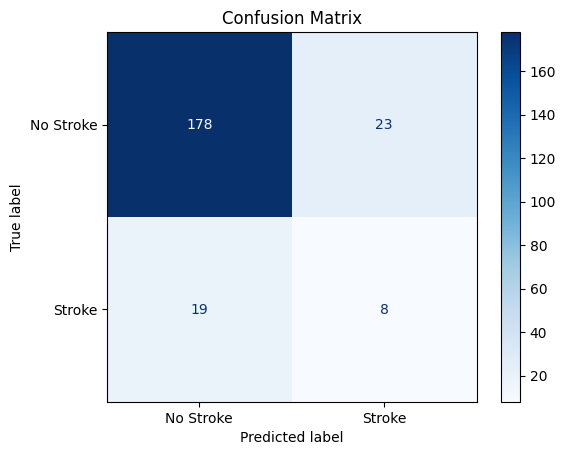

In [ ]:
# Make predictions on the test set
y_pred = model_pipe.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Display the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

> What is the overall accuracy?
>> The model hits 82% accuracy, but this is misleading. With 201 healthy patients vs. only 27 stroke patients, the model is largely just getting good at predicting the majority class — the class imbalance makes 82% an inflated and unreliable number.

---

>  False positive rate?
>> FP / (FP + TN) = 23 / (23 + 178) = ~11.4%
Roughly 1 in 9 healthy patients would receive an unnecessary stroke alert.

---

> False negative rate?
>> FN / (FN + TP) = 19 / (19 + 8) = ~70.4%
The model misses 7 out of 10 actual stroke patients — which is alarming.

---

> Which metric to optimize?
>> Recall (sensitivity) for the stroke class. Missing a real stroke patient is far more dangerous than sending a false alarm. The current recall of 0.30 means the model is catching only 30% of actual strokes — in a medical setting, that's unacceptable. You'd rather over-alert than under-alert.